<a href="https://colab.research.google.com/github/ishivamm/Predictive_maintenance_of_milling_machine/blob/main/Predictive_Maintenance_ML_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏭 Predictive Maintenance — Machine Failure Prediction

**End-to-End Machine Learning Pipeline**

This notebook builds a complete ML solution for predicting machine failures using the
[AI4I 2020 Predictive Maintenance Dataset](https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset).

**Pipeline Overview:**
1. Data Loading & Exploration
2. Exploratory Data Analysis (EDA) with rich visualizations
3. Feature Engineering
4. Data Preprocessing (encoding, scaling, imbalance handling)
5. Model Training (Logistic Regression, Random Forest, XGBoost)
6. Hyperparameter Tuning (RandomizedSearchCV)
7. Model Evaluation & Comparison
8. Feature Importance Analysis
9. Model Serialization & Prediction Function

---

## 1 · Environment Setup

In [1]:
!pip install xgboost imbalanced-learn shap -q

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not installed. Skipping XGBoost model.")

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score,
)

# Persistence
import joblib
import os

# Plotting defaults
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 120,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries loaded successfully.")
if XGBOOST_AVAILABLE:
    import xgboost
    print(f"   XGBoost version: {xgboost.__version__}")

✅ All libraries loaded successfully.
   XGBoost version: 3.2.0


---
## 2 · Data Loading & Initial Exploration

In [4]:
# ── Load dataset ────────────────────────────────────────────────────────────────
DATA_PATH = "ai4i2020.csv"   # Update if your CSV is elsewhere
df_raw = pd.read_csv(DATA_PATH)

print(f"📊 Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n")
df_raw.head(10)

📊 Dataset shape: 10,000 rows × 14 columns



,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


In [5]:
# Column names & data types
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
# Descriptive statistics for numerical features
df_raw.describe().T.style.background_gradient(cmap="YlOrRd", axis=1)

,count,mean,std,min,25%,50%,75%,max
UDI,10000.000000,5000.500000,2886.895680,1.000000,2500.750000,5000.500000,7500.250000,10000.000000
Air temperature [K],10000.000000,300.004930,2.000259,295.300000,298.300000,300.100000,301.500000,304.500000
Process temperature [K],10000.000000,310.005560,1.483734,305.700000,308.800000,310.100000,311.100000,313.800000
Rotational speed [rpm],10000.000000,1538.776100,179.284096,1168.000000,1423.000000,1503.000000,1612.000000,2886.000000
Torque [Nm],10000.000000,39.986910,9.968934,3.800000,33.200000,40.100000,46.800000,76.600000
Tool wear [min],10000.000000,107.951000,63.654147,0.000000,53.000000,108.000000,162.000000,253.000000
Machine failure,10000.000000,0.033900,0.180981,0.000000,0.000000,0.000000,0.000000,1.000000
TWF,10000.000000,0.004600,0.067671,0.000000,0.000000,0.000000,0.000000,1.000000
HDF,10000.000000,0.011500,0.106625,0.000000,0.000000,0.000000,0.000000,1.000000
PWF,10000.000000,0.009500,0.097009,0.000000,0.000000,0.000000,0.000000,1.000000


In [7]:
# Missing-value audit
missing = df_raw.isnull().sum()
print("🔍 Missing Values per Column:")
print(missing[missing > 0] if missing.sum() > 0 else "   ✅ No missing values detected.\n")

🔍 Missing Values per Column:
   ✅ No missing values detected.



In [9]:
# Unique values per column
print(" Unique values per column:\n")
for col in df_raw.columns:
    print(f"  {col:30s} → {df_raw[col].nunique():>6,}  unique")

 Unique values per column:

  UDI                            → 10,000  unique
  Product ID                     → 10,000  unique
  Type                           →      3  unique
  Air temperature [K]            →     93  unique
  Process temperature [K]        →     82  unique
  Rotational speed [rpm]         →    941  unique
  Torque [Nm]                    →    577  unique
  Tool wear [min]                →    246  unique
  Machine failure                →      2  unique
  TWF                            →      2  unique
  HDF                            →      2  unique
  PWF                            →      2  unique
  OSF                            →      2  unique
  RNF                            →      2  unique


---
## 3 · Exploratory Data Analysis (EDA)

We perform a thorough visual exploration to understand distributions,
relationships, and class imbalance before building models.

### 3.1 · Target Variable Distribution

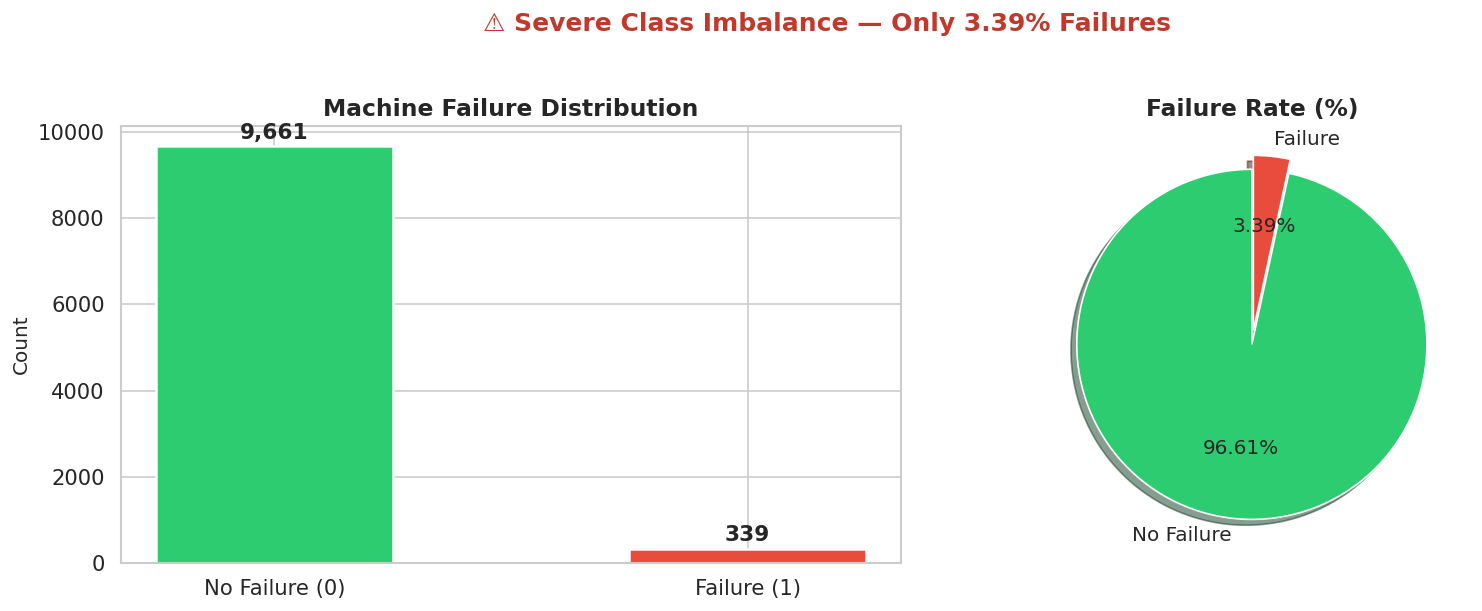

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ["#2ecc71", "#e74c3c"]
counts = df_raw["Machine failure"].value_counts()
bars = axes[0].bar(["No Failure (0)", "Failure (1)"], counts.values, color=colors,
                   edgecolor="white", linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
                 f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=13)
axes[0].set_title("Machine Failure Distribution", fontweight="bold")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(counts.values, labels=["No Failure", "Failure"],
            autopct="%1.2f%%", colors=colors, startangle=90,
            explode=(0, 0.08), shadow=True, textprops={"fontsize": 12})
axes[1].set_title("Failure Rate (%)", fontweight="bold")

plt.suptitle("⚠️ Severe Class Imbalance — Only 3.39% Failures",
             fontsize=15, fontweight="bold", y=1.02, color="#c0392b")
plt.tight_layout()
plt.show()

### 3.2 · Product Quality Type Distribution

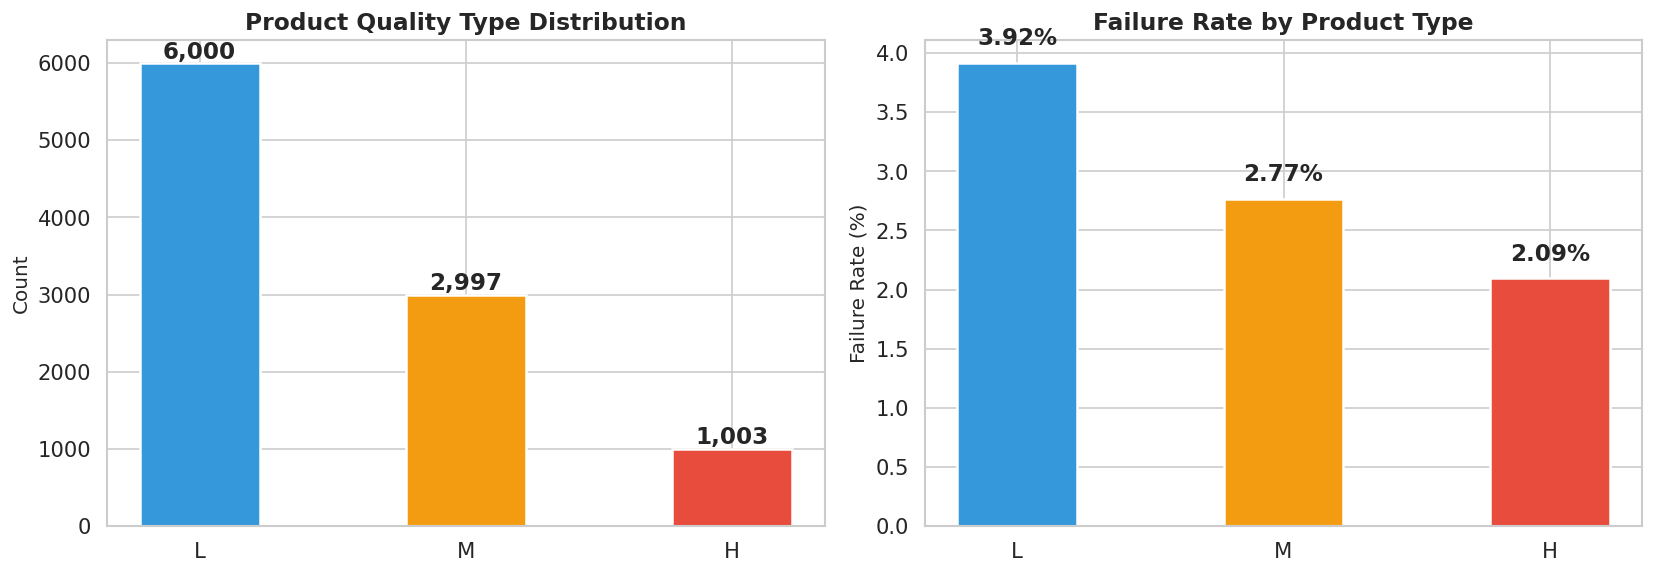

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_colors = {"L": "#3498db", "M": "#f39c12", "H": "#e74c3c"}

# Overall distribution
type_counts = df_raw["Type"].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=[type_colors[t] for t in type_counts.index],
            edgecolor="white", linewidth=1.5, width=0.45)
for i, (idx, val) in enumerate(zip(type_counts.index, type_counts.values)):
    axes[0].text(i, val + 60, f"{val:,}", ha="center", fontweight="bold")
axes[0].set_title("Product Quality Type Distribution", fontweight="bold")
axes[0].set_ylabel("Count")

# Failure rate by type
failure_by_type = df_raw.groupby("Type")["Machine failure"].mean().sort_values(ascending=False) * 100
bars = axes[1].bar(failure_by_type.index, failure_by_type.values,
                   color=[type_colors[t] for t in failure_by_type.index],
                   edgecolor="white", linewidth=1.5, width=0.45)
for bar, val in zip(bars, failure_by_type.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
                 f"{val:.2f}%", ha="center", fontweight="bold")
axes[1].set_title("Failure Rate by Product Type", fontweight="bold")
axes[1].set_ylabel("Failure Rate (%)")

plt.tight_layout()
plt.show()

### 3.3 · Feature Distributions

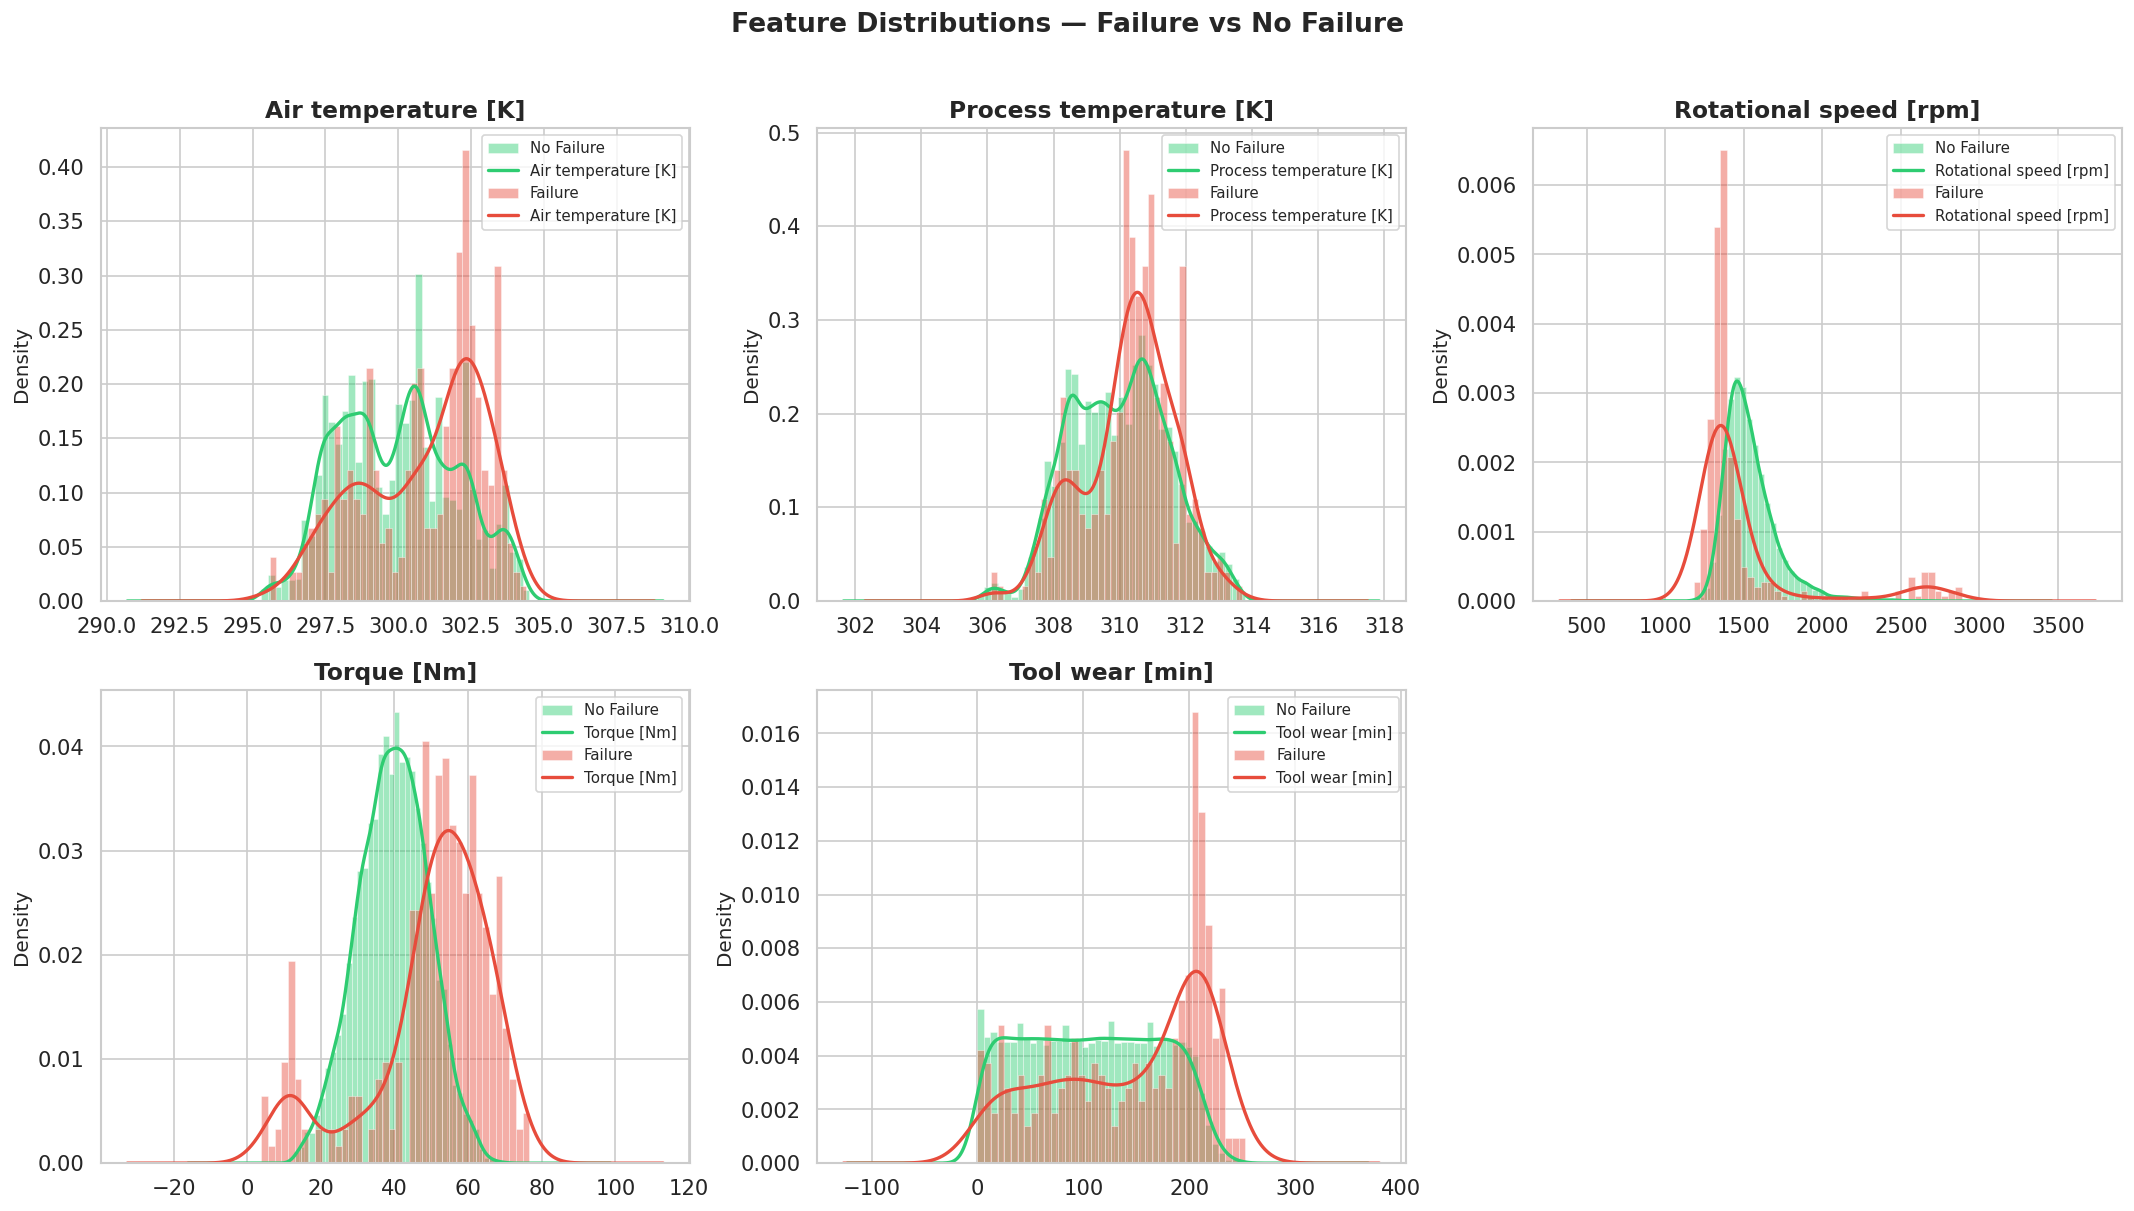

In [12]:
numeric_features = [
    "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_features):
    ax = axes[i]
    # KDE + histogram split by failure
    for label, color, lbl_text in zip([0, 1], ["#2ecc71", "#e74c3c"], ["No Failure", "Failure"]):
        subset = df_raw[df_raw["Machine failure"] == label][col]
        ax.hist(subset, bins=40, alpha=0.45, color=color, label=lbl_text, density=True,
                edgecolor="white", linewidth=0.5)
        subset.plot.kde(ax=ax, color=color, linewidth=2)
    ax.set_title(col, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_ylabel("Density")

# Hide the extra subplot
axes[-1].set_visible(False)
plt.suptitle("Feature Distributions — Failure vs No Failure", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.4 · Box Plots — Outlier & Spread Analysis

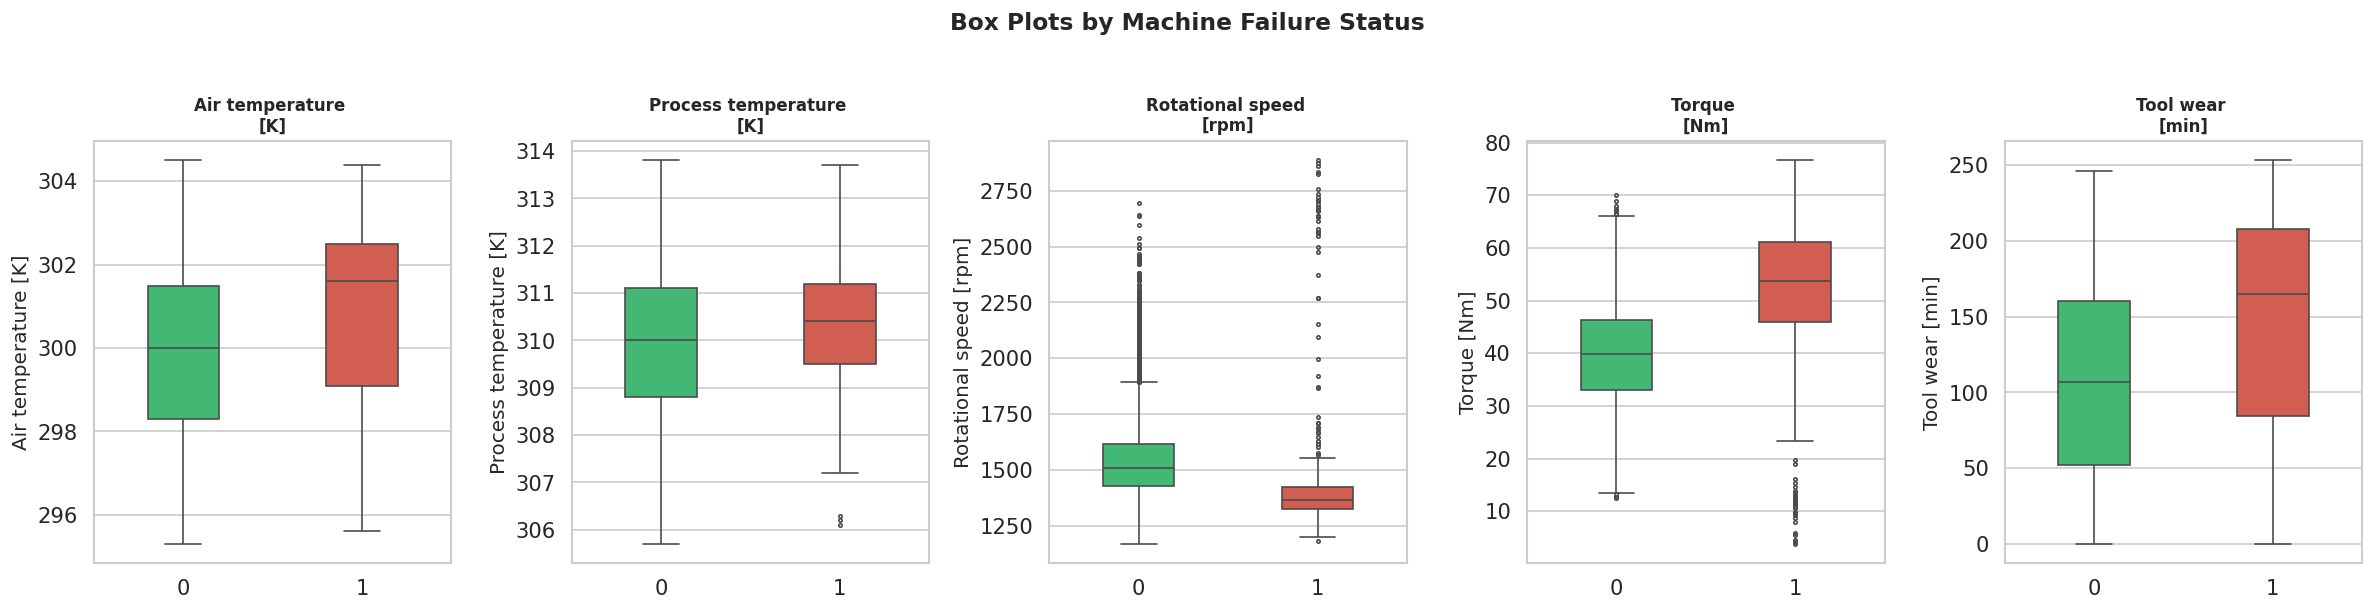

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(numeric_features):
    sns.boxplot(x="Machine failure", y=col, data=df_raw, ax=axes[i],
                palette=["#2ecc71", "#e74c3c"], width=0.4, fliersize=2)
    axes[i].set_title(col.replace("[", "\n["), fontweight="bold", fontsize=10)
    axes[i].set_xlabel("")
plt.suptitle("Box Plots by Machine Failure Status", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.5 · Correlation Heatmap

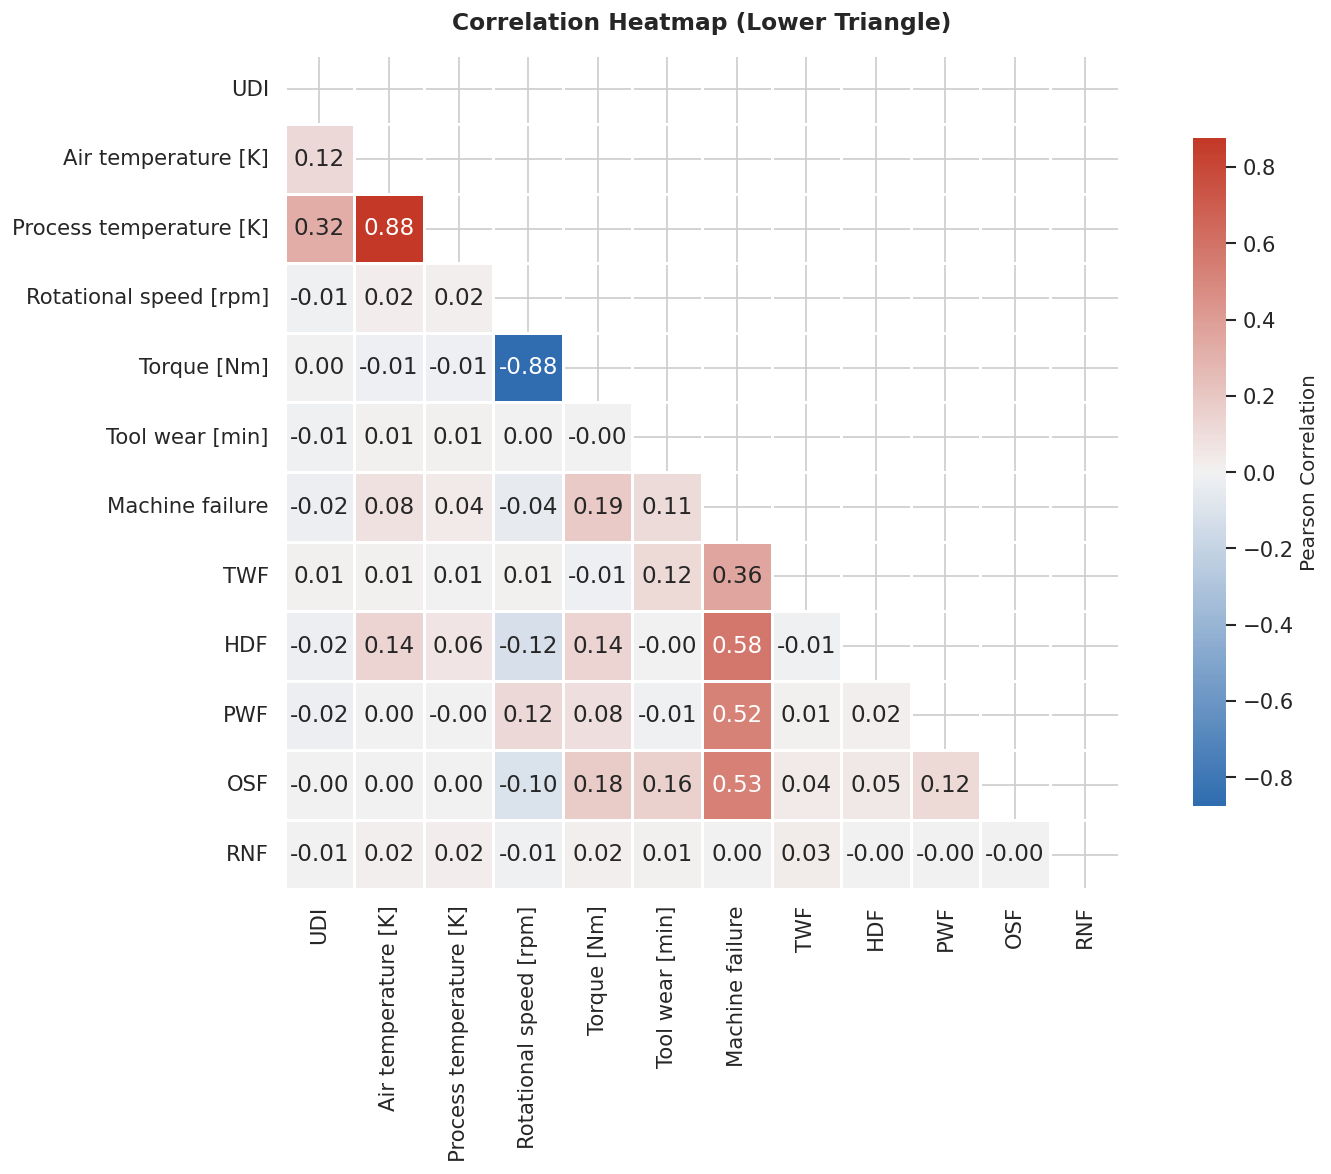

In [14]:
# Select only numeric columns for correlation
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
corr_matrix = df_raw[numeric_cols].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
cmap = sns.diverging_palette(250, 15, s=85, l=45, n=9, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap=cmap,
            center=0, square=True, linewidths=0.8, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"})
ax.set_title("Correlation Heatmap (Lower Triangle)", fontweight="bold", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### 3.6 · Pair Plot — Key Features

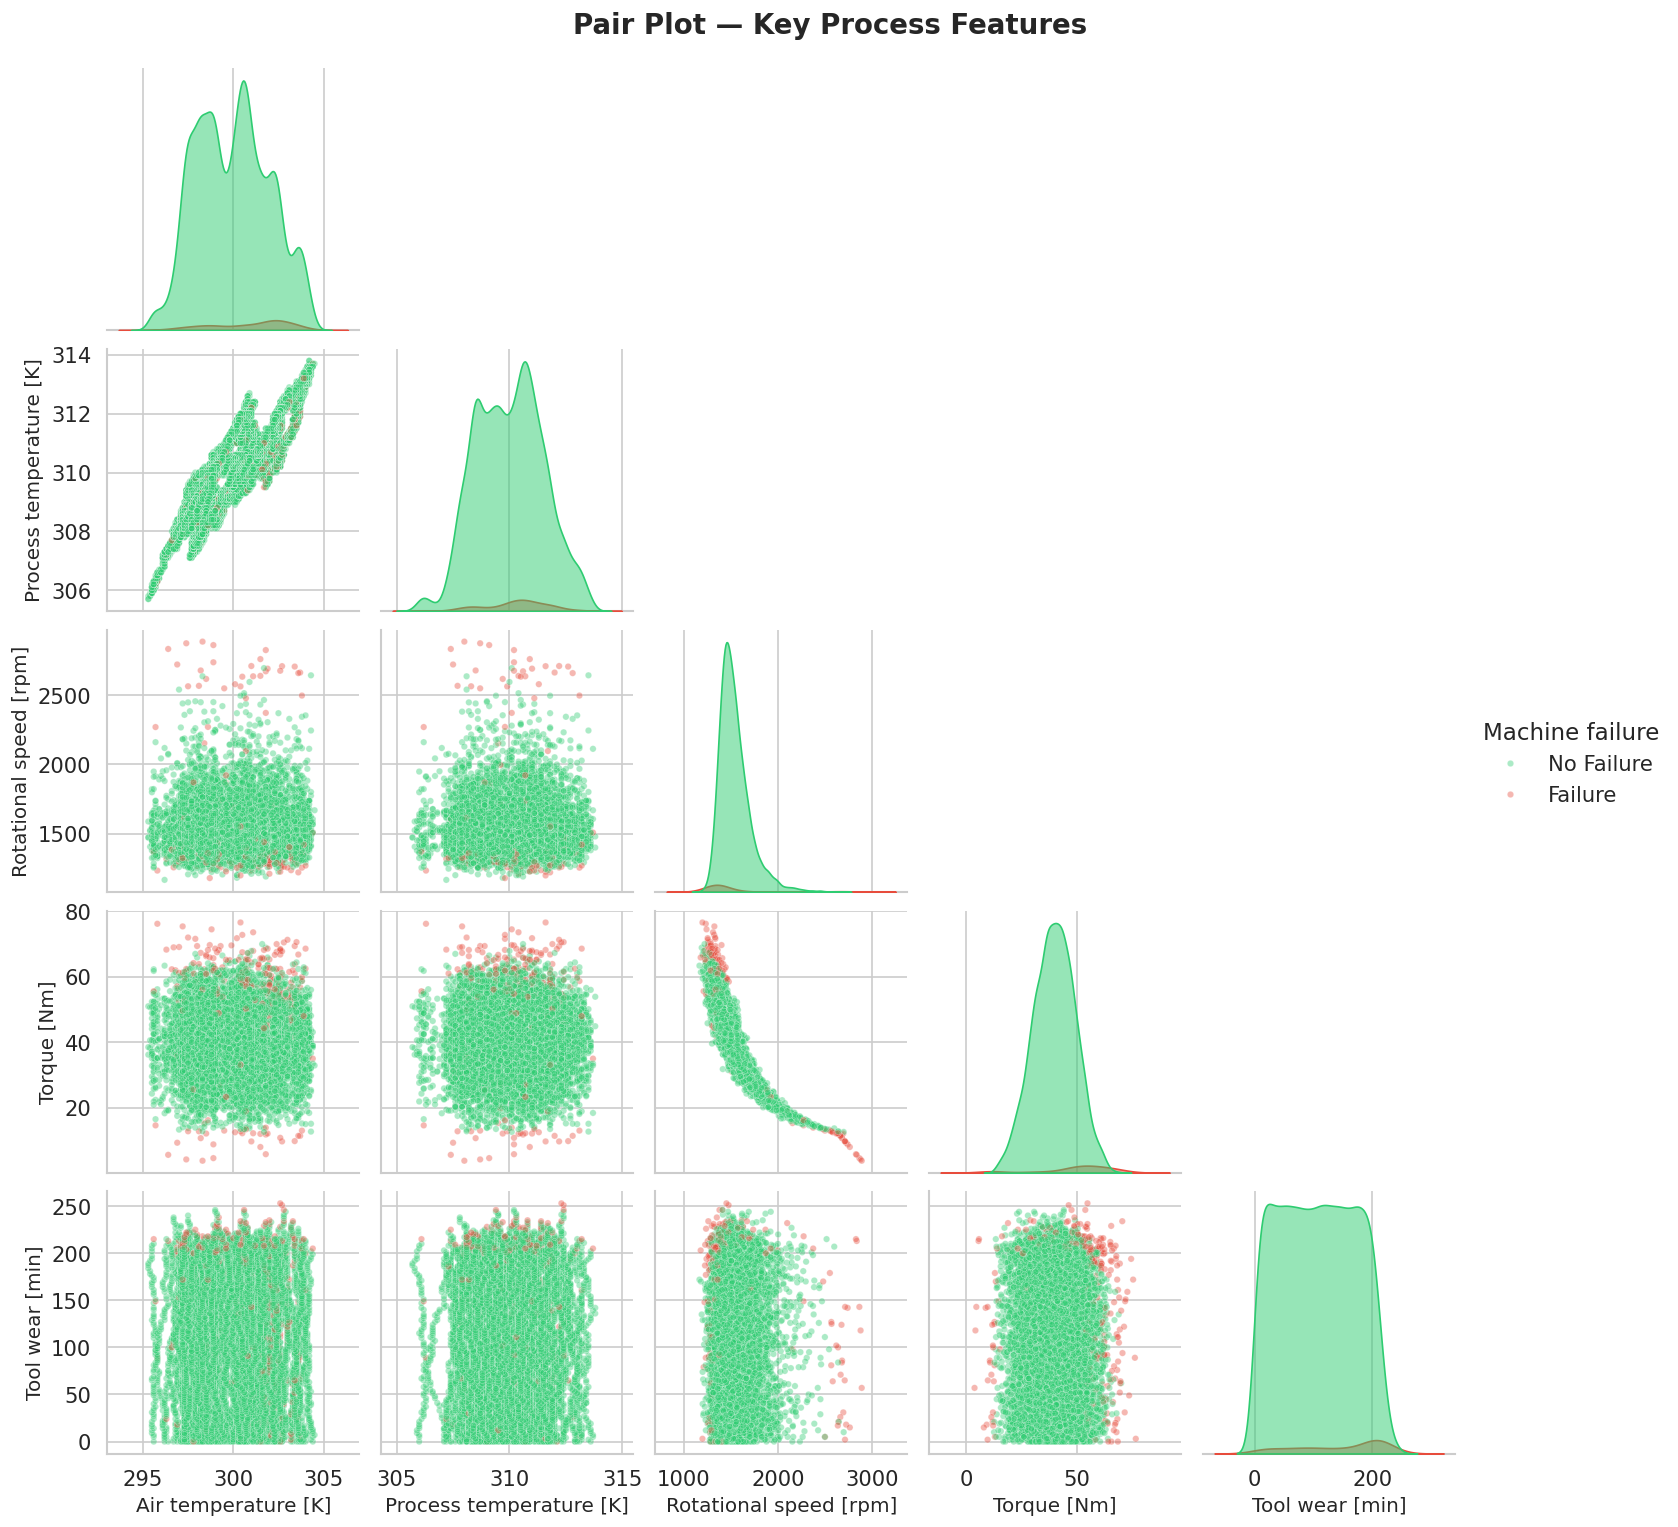

In [15]:
pair_cols = ["Air temperature [K]", "Process temperature [K]",
             "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]",
             "Machine failure"]
sample_df = df_raw[pair_cols].copy()
sample_df["Machine failure"] = sample_df["Machine failure"].map({0: "No Failure", 1: "Failure"})

g = sns.pairplot(sample_df, hue="Machine failure", diag_kind="kde",
                 palette={"No Failure": "#2ecc71", "Failure": "#e74c3c"},
                 plot_kws={"alpha": 0.4, "s": 15}, diag_kws={"fill": True, "alpha": 0.5},
                 corner=True)
g.figure.suptitle("Pair Plot — Key Process Features", fontweight="bold", y=1.02)
plt.show()

### 3.7 · Failure Type Breakdown

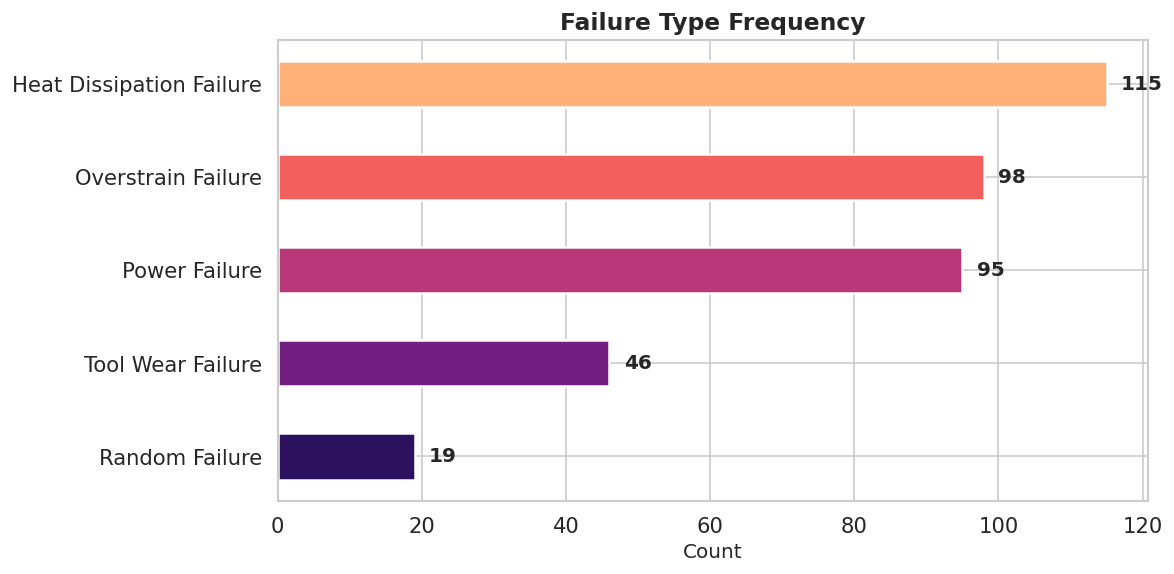

In [16]:
failure_types = ["TWF", "HDF", "PWF", "OSF", "RNF"]
failure_counts = df_raw[failure_types].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors_ft = sns.color_palette("magma", len(failure_types))
bars = ax.barh(failure_counts.index, failure_counts.values, color=colors_ft,
               edgecolor="white", linewidth=1.5, height=0.5)
for bar, val in zip(bars, failure_counts.values):
    ax.text(val + 2, bar.get_y() + bar.get_height() / 2, f"{val}",
            va="center", fontweight="bold", fontsize=12)

labels_map = {
    "TWF": "Tool Wear Failure",
    "HDF": "Heat Dissipation Failure",
    "PWF": "Power Failure",
    "OSF": "Overstrain Failure",
    "RNF": "Random Failure",
}
ax.set_yticklabels([labels_map.get(t, t) for t in failure_counts.index])
ax.set_title("Failure Type Frequency", fontweight="bold")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

---
## 4 · Feature Engineering

We create domain-driven features that can improve model performance:
- **Temperature difference** (ΔT)
- **Power** = Torque × Rotational Speed
- **Torque-to-speed ratio**
- **Wear-torque interaction**
- **Total concurrent failure modes**

In [17]:
df = df_raw.copy()

# ── Drop identifier columns ────────────────────────────────────────────────────
df.drop(columns=["UDI", "Product ID"], inplace=True)

# ── Engineered features ────────────────────────────────────────────────────────
# 1. Temperature difference: process temp is always higher than air temp
df["Temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]

# 2. Power (proportional): Torque × Rotational Speed
df["Power"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"]

# 3. Torque-to-speed ratio: high ratio → high strain
df["Torque_speed_ratio"] = df["Torque [Nm]"] / (df["Rotational speed [rpm]"] + 1e-9)

# 4. Wear × Torque interaction: worn tool under high torque → higher failure risk
df["Wear_torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]

# 5. Total number of concurrent failure types flagged
df["Failure_mode_count"] = df[["TWF", "HDF", "PWF", "OSF", "RNF"]].sum(axis=1)

print("✅ Feature engineering complete.")
print(f"   New shape: {df.shape}")
print(f"   New columns: {['Temp_diff', 'Power', 'Torque_speed_ratio', 'Wear_torque', 'Failure_mode_count']}")
df.head()

✅ Feature engineering complete.
   New shape: (10000, 17)
   New columns: ['Temp_diff', 'Power', 'Torque_speed_ratio', 'Wear_torque', 'Failure_mode_count']


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temp_diff,Power,Torque_speed_ratio,Wear_torque,Failure_mode_count
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.027595,0.0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,0.032884,138.9,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,0.032977,247.0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,0.027565,276.5,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,0.028409,360.0,0


---
## 5 · Data Preprocessing

Steps:
1. Encode the categorical `Type` column
2. Define feature matrix **X** and target **y**
3. Train / test split (stratified)
4. Scale numerical features
5. Handle class imbalance with **SMOTE**

In [18]:
# ── 5.1 Encode categorical variable ────────────────────────────────────────────
le_type = LabelEncoder()
df["Type_encoded"] = le_type.fit_transform(df["Type"])

# Also create one-hot encoding for modeling flexibility
type_dummies = pd.get_dummies(df["Type"], prefix="Type", drop_first=False).astype(int)
df = pd.concat([df, type_dummies], axis=1)

print("Label encoding mapping:", dict(zip(le_type.classes_, le_type.transform(le_type.classes_))))
print("One-hot columns added:", type_dummies.columns.tolist())

Label encoding mapping: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}
One-hot columns added: ['Type_H', 'Type_L', 'Type_M']


In [19]:
# ── 5.2 Define X and y ─────────────────────────────────────────────────────────
# Drop original categorical column, individual failure type columns (leakage), and target
drop_cols = ["Type", "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
# NOTE: We drop individual failure-type columns (TWF, HDF, etc.) because they are
# direct indicators of the target — using them would be DATA LEAKAGE.
# The 'Failure_mode_count' is an aggregate and less leaky, but for a strict
# no-leakage model, you could remove it too.

# Actually, to be safe, let's also drop Failure_mode_count for the primary model
# since it's derived from failure-type flags which are essentially labels.
drop_cols.append("Failure_mode_count")

X = df.drop(columns=drop_cols)
y = df["Machine failure"]

# Sanitize column names: XGBoost v3+ forbids [, ], < in feature names
X.columns = [c.replace("[", "_").replace("]", "").replace("<", "_") for c in X.columns]

feature_names = X.columns.tolist()
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Target distribution:\n{y.value_counts()}")

Features (13): ['Air temperature _K', 'Process temperature _K', 'Rotational speed _rpm', 'Torque _Nm', 'Tool wear _min', 'Temp_diff', 'Power', 'Torque_speed_ratio', 'Wear_torque', 'Type_encoded', 'Type_H', 'Type_L', 'Type_M']
Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [20]:
# ── 5.3 Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set: {X_train.shape[0]:,} samples  |  Failure rate: {y_train.mean():.4f}")
print(f"Test set:  {X_test.shape[0]:,} samples  |  Failure rate: {y_test.mean():.4f}")

Train set: 8,000 samples  |  Failure rate: 0.0339
Test set:  2,000 samples  |  Failure rate: 0.0340


In [21]:
# ── 5.4 Feature Scaling ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)

print("✅ Features standardized (mean ≈ 0, std ≈ 1).")

✅ Features standardized (mean ≈ 0, std ≈ 1).



Before SMOTE:  {0: np.int64(7729), 1: np.int64(271)}
After  SMOTE:  {0: np.int64(7729), 1: np.int64(7729)}


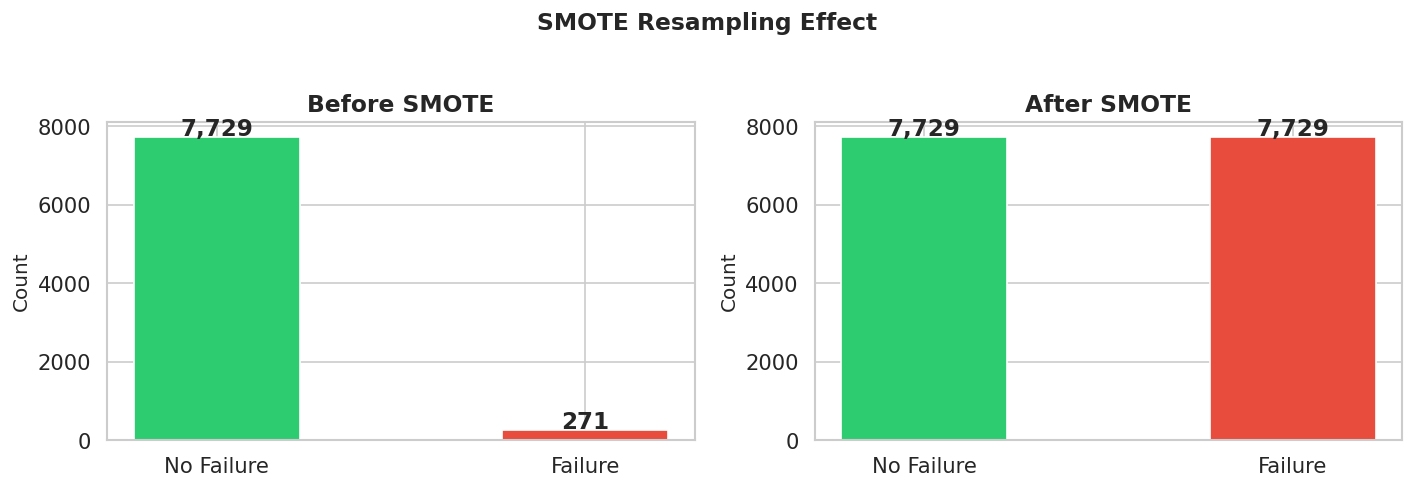

In [22]:
# ── 5.5 Handle Class Imbalance with SMOTE ──────────────────────────────────────
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy="minority")
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nBefore SMOTE:  {dict(pd.Series(y_train).value_counts())}")
print(f"After  SMOTE:  {dict(pd.Series(y_train_resampled).value_counts())}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in zip(axes,
                            [y_train, y_train_resampled],
                            ["Before SMOTE", "After SMOTE"]):
    counts = pd.Series(data).value_counts()
    ax.bar(["No Failure", "Failure"], counts.values, color=["#2ecc71", "#e74c3c"],
           edgecolor="white", width=0.45)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, f"{v:,}", ha="center", fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Count")
plt.suptitle("SMOTE Resampling Effect", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 6 · Model Training

We train three models:
1. **Logistic Regression** — interpretable baseline
2. **Random Forest** — ensemble, handles non-linearity
3. **XGBoost** — gradient boosting, state-of-the-art for tabular data

In [23]:
# ── Helper: Evaluate a trained model ───────────────────────────────────────────
def evaluate_model(model, X_eval, y_eval, model_name="Model"):
    """Evaluate a classifier and return a dict of metrics + print a report."""
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1-Score": f1_score(y_eval, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, y_prob) if y_prob is not None else None,
    }

    print(f"\n{'='*60}")
    print(f"  📈 {model_name} — Evaluation Results")
    print(f"{'='*60}")
    for k, v in metrics.items():
        if k != "Model" and v is not None:
            print(f"    {k:<12s}: {v:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_eval, y_pred, target_names=["No Failure", "Failure"]))

    return metrics, y_pred, y_prob


def plot_confusion_matrix(y_true, y_pred, model_name, ax=None):
    """Plot a styled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Fail", "Fail"],
                yticklabels=["No Fail", "Fail"],
                linewidths=1, linecolor="white", cbar=False,
                annot_kws={"size": 14, "weight": "bold"})
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.set_title(f"{model_name}", fontweight="bold", fontsize=12)

In [24]:
# ── 6.1 Logistic Regression ────────────────────────────────────────────────────
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",  # additional weight handling
    random_state=RANDOM_STATE,
    solver="lbfgs",
)
lr_model.fit(X_train_resampled, y_train_resampled)

lr_metrics, lr_pred, lr_prob = evaluate_model(lr_model, X_test_scaled, y_test, "Logistic Regression")


  📈 Logistic Regression — Evaluation Results
    Accuracy    : 0.8635
    Precision   : 0.1846
    Recall      : 0.8824
    F1-Score    : 0.3053
    ROC-AUC     : 0.9388

  Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      0.86      0.92      1932
     Failure       0.18      0.88      0.31        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000



In [25]:
# ── 6.2 Random Forest ──────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train_resampled, y_train_resampled)

rf_metrics, rf_pred, rf_prob = evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")


  📈 Random Forest — Evaluation Results
    Accuracy    : 0.9680
    Precision   : 0.5182
    Recall      : 0.8382
    F1-Score    : 0.6404
    ROC-AUC     : 0.9815

  Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      1932
     Failure       0.52      0.84      0.64        68

    accuracy                           0.97      2000
   macro avg       0.76      0.91      0.81      2000
weighted avg       0.98      0.97      0.97      2000



In [27]:
# ── 6.3 XGBoost ────────────────────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    # Calculate scale_pos_weight for imbalance
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgb_model.fit(X_train_resampled, y_train_resampled)

    xgb_metrics, xgb_pred, xgb_prob = evaluate_model(xgb_model, X_test_scaled, y_test, "XGBoost")
else:
    print("⚠️  XGBoost skipped (not installed).")


  📈 XGBoost — Evaluation Results
    Accuracy    : 0.9620
    Precision   : 0.4688
    Recall      : 0.8824
    F1-Score    : 0.6122
    ROC-AUC     : 0.9838

  Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      0.96      0.98      1932
     Failure       0.47      0.88      0.61        68

    accuracy                           0.96      2000
   macro avg       0.73      0.92      0.80      2000
weighted avg       0.98      0.96      0.97      2000



---
## 7 · Hyperparameter Tuning

We use **RandomizedSearchCV** with stratified 5-fold CV for efficiency.
Tuning is applied to Random Forest and XGBoost (the top performers).

In [28]:
# ── 7.1 Tune Random Forest ─────────────────────────────────────────────────────
rf_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [8, 12, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", "balanced_subsample"],
}

# NOTE: Increase n_iter (e.g., 40-60) and n_splits (e.g., 5) in Colab for
# more thorough tuning. Reduced here for faster local execution.
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="f1",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train_resampled, y_train_resampled)

print(f"\n🏆 Best RF params: {rf_search.best_params_}")
print(f"   Best CV F1:     {rf_search.best_score_:.4f}")

rf_tuned = rf_search.best_estimator_
rf_tuned_metrics, rf_tuned_pred, rf_tuned_prob = evaluate_model(
    rf_tuned, X_test_scaled, y_test, "Random Forest (Tuned)"
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits

🏆 Best RF params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'class_weight': 'balanced'}
   Best CV F1:     0.9807

  📈 Random Forest (Tuned) — Evaluation Results
    Accuracy    : 0.9695
    Precision   : 0.5327
    Recall      : 0.8382
    F1-Score    : 0.6514
    ROC-AUC     : 0.9805

  Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      1932
     Failure       0.53      0.84      0.65        68

    accuracy                           0.97      2000
   macro avg       0.76      0.91      0.82      2000
weighted avg       0.98      0.97      0.97      2000



In [29]:
# ── 7.2 Tune XGBoost ───────────────────────────────────────────────────────────
if XGBOOST_AVAILABLE:
    xgb_param_dist = {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 5, 6, 8, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
        "reg_alpha": [0, 0.01, 0.1, 1],
        "reg_lambda": [0.5, 1, 2, 5],
        "min_child_weight": [1, 3, 5, 7],
    }

    # NOTE: Increase n_iter (e.g., 50-80) and n_splits (e.g., 5) in Colab.
    xgb_search = RandomizedSearchCV(
        XGBClassifier(
            eval_metric="logloss",
            scale_pos_weight=scale_pos,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        param_distributions=xgb_param_dist,
        n_iter=20,
        scoring="f1",
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )
    xgb_search.fit(X_train_resampled, y_train_resampled)

    print(f"\n🏆 Best XGB params: {xgb_search.best_params_}")
    print(f"   Best CV F1:      {xgb_search.best_score_:.4f}")

    xgb_tuned = xgb_search.best_estimator_
    xgb_tuned_metrics, xgb_tuned_pred, xgb_tuned_prob = evaluate_model(
        xgb_tuned, X_test_scaled, y_test, "XGBoost (Tuned)"
    )

Fitting 3 folds for each of 20 candidates, totalling 60 fits

🏆 Best XGB params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
   Best CV F1:      0.9833

  📈 XGBoost (Tuned) — Evaluation Results
    Accuracy    : 0.9640
    Precision   : 0.4836
    Recall      : 0.8676
    F1-Score    : 0.6211
    ROC-AUC     : 0.9791

  Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      0.97      0.98      1932
     Failure       0.48      0.87      0.62        68

    accuracy                           0.96      2000
   macro avg       0.74      0.92      0.80      2000
weighted avg       0.98      0.96      0.97      2000



---
## 8 · Model Comparison & Evaluation

In [30]:
# ── 8.1 Collect all metrics ────────────────────────────────────────────────────
all_metrics = [lr_metrics, rf_metrics, rf_tuned_metrics]
all_preds = {"Logistic Regression": (lr_pred, lr_prob),
             "Random Forest": (rf_pred, rf_prob),
             "Random Forest (Tuned)": (rf_tuned_pred, rf_tuned_prob)}

if XGBOOST_AVAILABLE:
    all_metrics.extend([xgb_metrics, xgb_tuned_metrics])
    all_preds["XGBoost"] = (xgb_pred, xgb_prob)
    all_preds["XGBoost (Tuned)"] = (xgb_tuned_pred, xgb_tuned_prob)

results_df = pd.DataFrame(all_metrics).set_index("Model")
results_df = results_df.sort_values("F1-Score", ascending=False)

print("\n📊 Model Comparison Table (sorted by F1-Score):\n")
display_df = results_df.style.format("{:.4f}").background_gradient(
    cmap="RdYlGn", axis=0, subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
).set_properties(**{"text-align": "center"})
display(display_df) if "display" in dir() else print(results_df.round(4))


📊 Model Comparison Table (sorted by F1-Score):

                       Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                
Random Forest (Tuned)    0.9695     0.5327  0.8382    0.6514   0.9805
Random Forest            0.9680     0.5182  0.8382    0.6404   0.9815
XGBoost (Tuned)          0.9640     0.4836  0.8676    0.6211   0.9791
XGBoost                  0.9620     0.4688  0.8824    0.6122   0.9838
Logistic Regression      0.8635     0.1846  0.8824    0.3053   0.9388


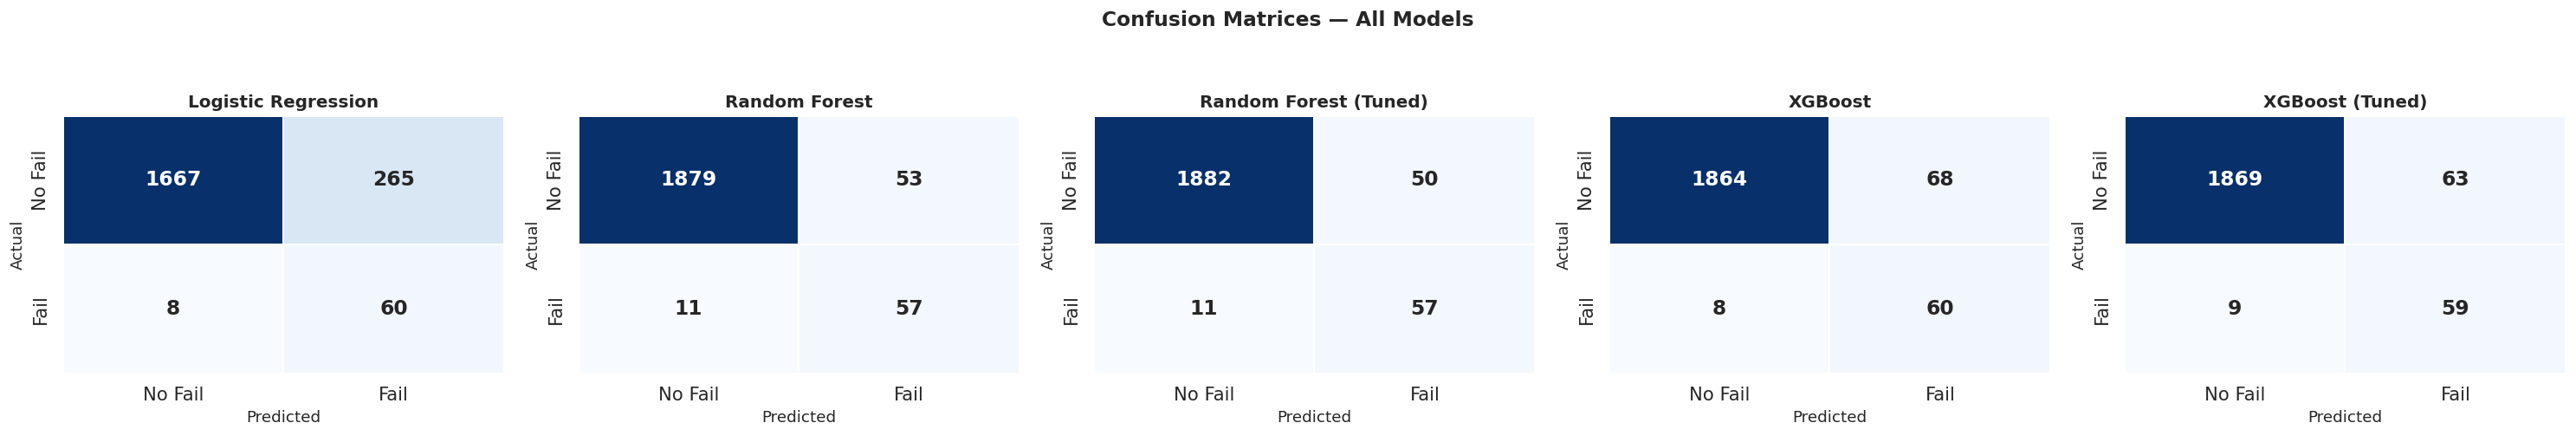

In [31]:
# ── 8.2 Confusion Matrices ─────────────────────────────────────────────────────
n_models = len(all_preds)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, (pred, prob)) in zip(axes, all_preds.items()):
    plot_confusion_matrix(y_test, pred, name, ax=ax)

plt.suptitle("Confusion Matrices — All Models", fontweight="bold", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

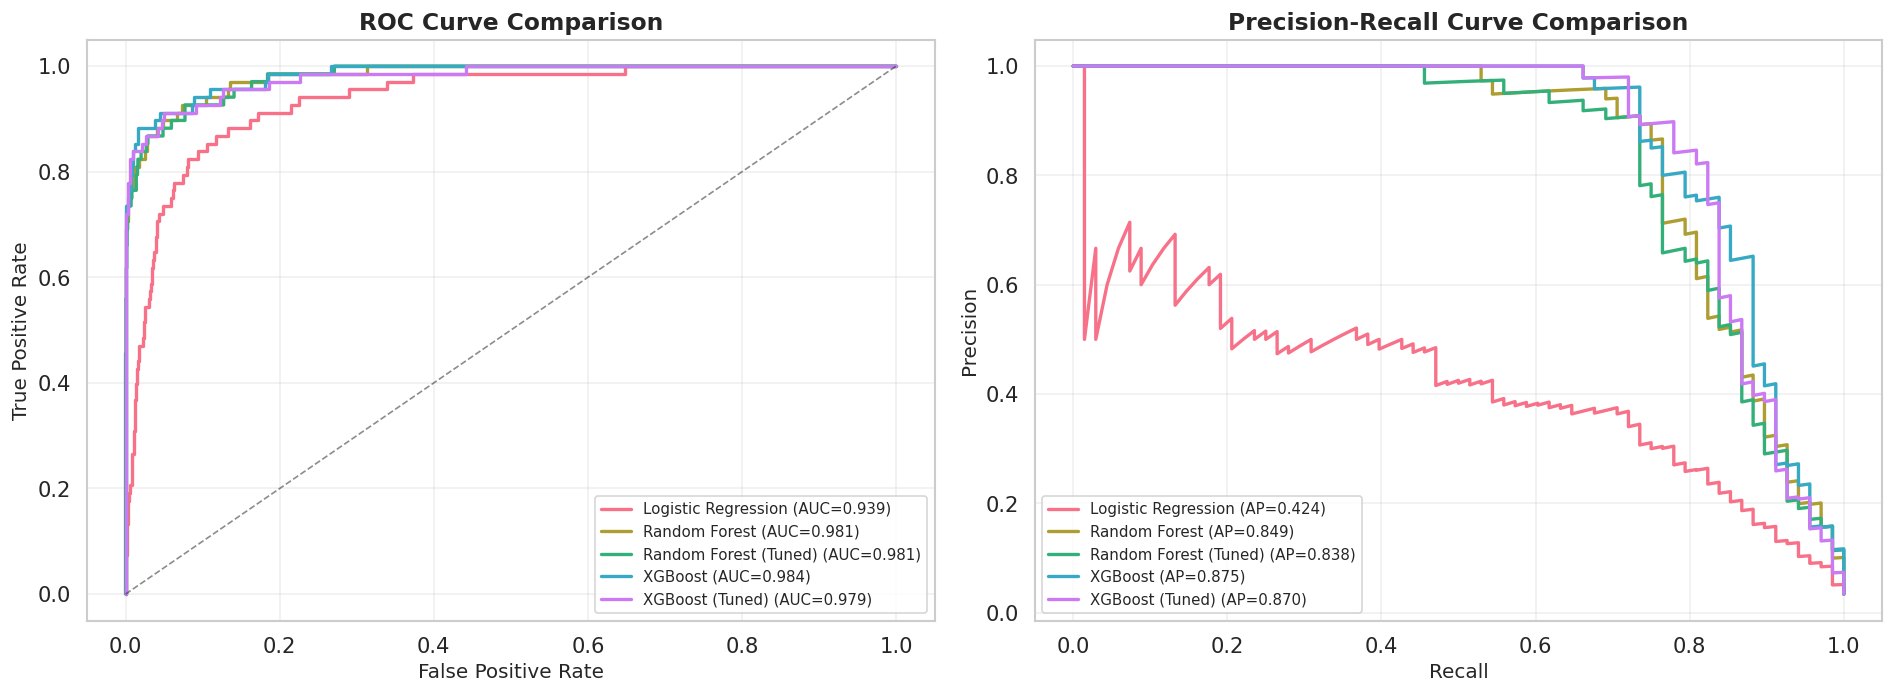

In [32]:
# ── 8.3 ROC Curves ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
ax = axes[0]
colors_roc = sns.color_palette("husl", n_models)
for (name, (pred, prob)), color in zip(all_preds.items(), colors_roc):
    if prob is not None:
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc_val = roc_auc_score(y_test, prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

# Precision-Recall Curve
ax = axes[1]
for (name, (pred, prob)), color in zip(all_preds.items(), colors_roc):
    if prob is not None:
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, prob)
        ap = average_precision_score(y_test, prob)
        ax.plot(recall_vals, precision_vals, label=f"{name} (AP={ap:.3f})", color=color, linewidth=2)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve Comparison", fontweight="bold")
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

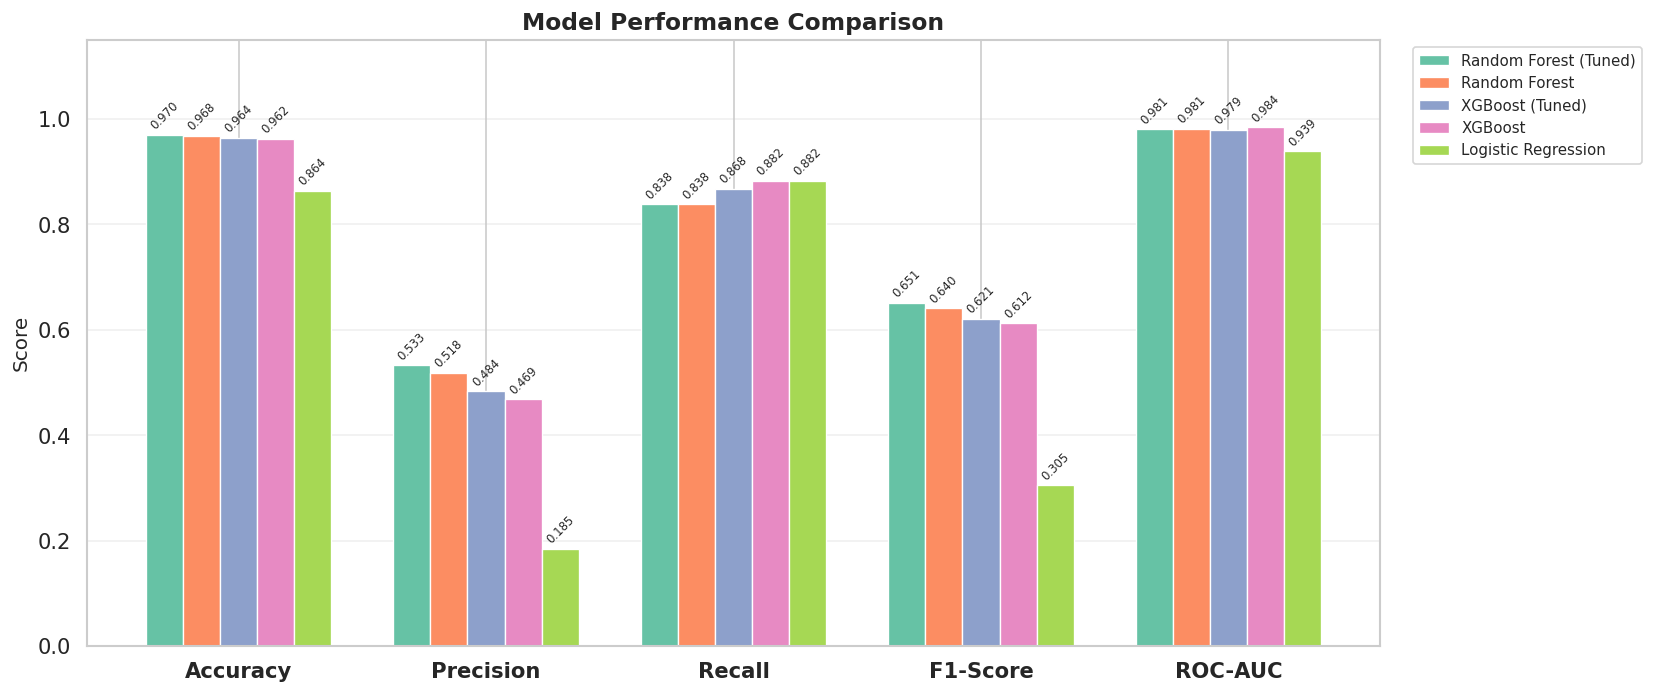

In [33]:
# ── 8.4 Bar Chart Comparison ───────────────────────────────────────────────────
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(metrics_to_plot))
width = 0.15
model_names = results_df.index.tolist()
colors_bar = sns.color_palette("Set2", len(model_names))

for i, (model, color) in enumerate(zip(model_names, colors_bar)):
    vals = [results_df.loc[model, m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metrics_to_plot, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison", fontweight="bold", fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9 · Select Best Model

In [34]:
best_model_name = results_df["F1-Score"].idxmax()
print(f"🏆 Best Model (by F1-Score): {best_model_name}")
print(f"   F1 = {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"   ROC-AUC = {results_df.loc[best_model_name, 'ROC-AUC']:.4f}")

# Get the actual model object
model_lookup = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Random Forest (Tuned)": rf_tuned,
}
if XGBOOST_AVAILABLE:
    model_lookup["XGBoost"] = xgb_model
    model_lookup["XGBoost (Tuned)"] = xgb_tuned

best_model = model_lookup[best_model_name]
print(f"\n✅ Best model selected: {best_model_name}")

🏆 Best Model (by F1-Score): Random Forest (Tuned)
   F1 = 0.6514
   ROC-AUC = 0.9805

✅ Best model selected: Random Forest (Tuned)


---
## 10 · Feature Importance Analysis

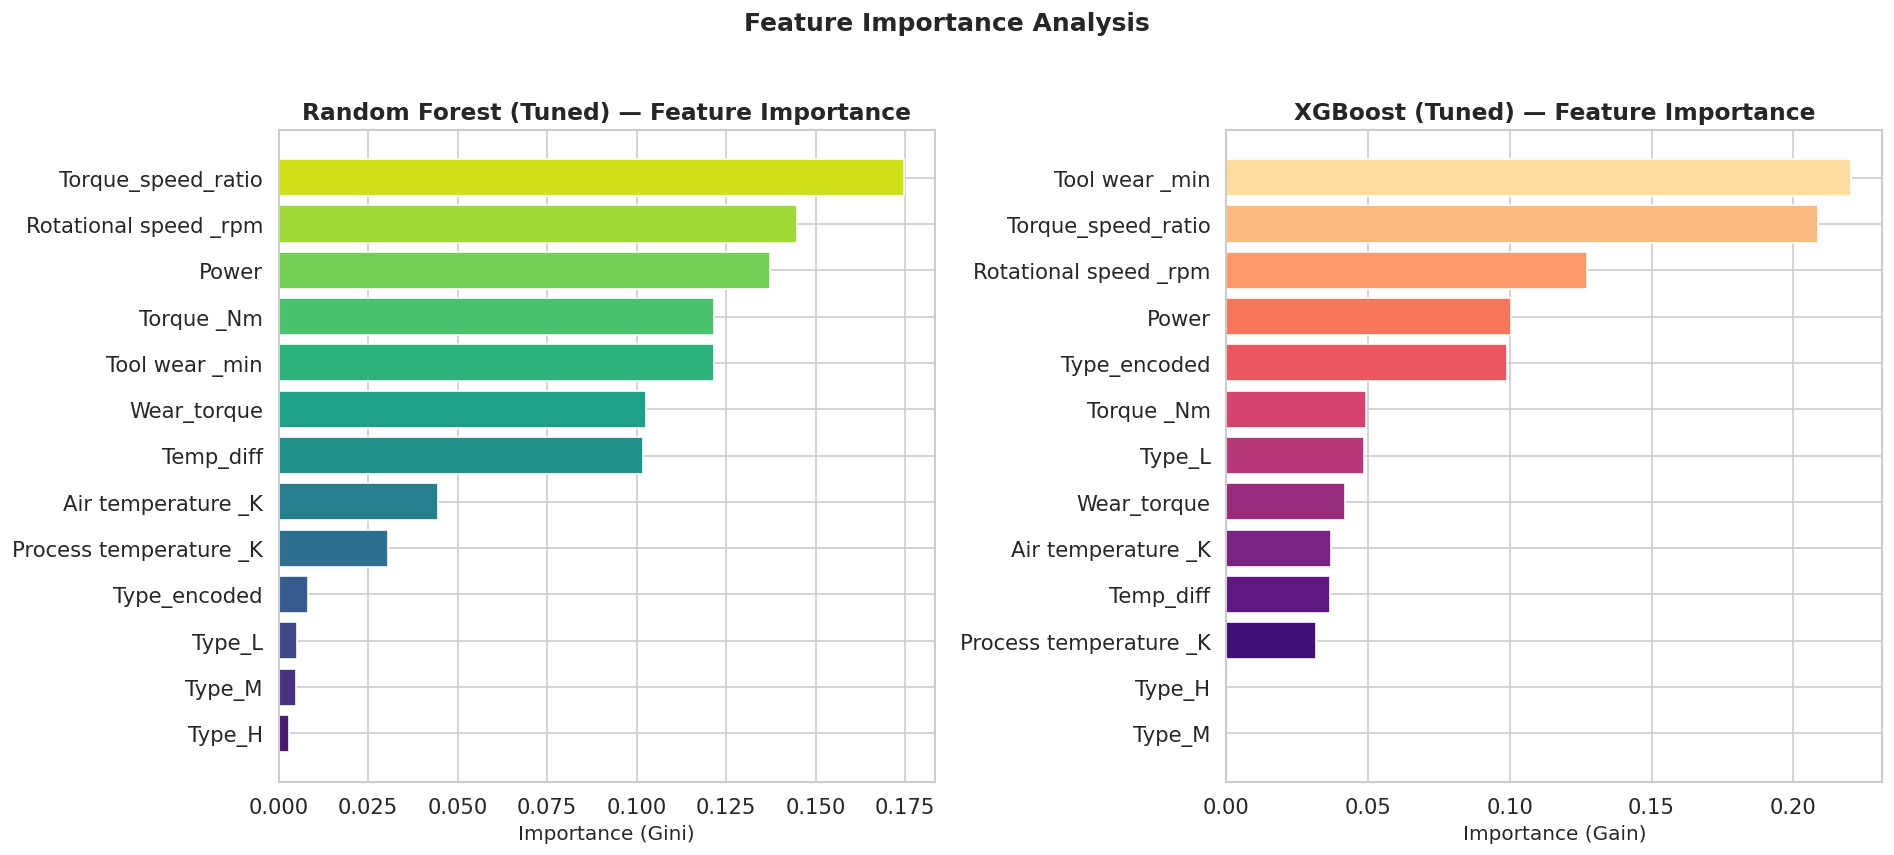

In [35]:
# ── 10.1 Feature Importance from tree-based models ─────────────────────────────
fig, axes = plt.subplots(1, 2 if XGBOOST_AVAILABLE else 1, figsize=(16, 7))
if not isinstance(axes, np.ndarray):
    axes = [axes]

# Random Forest (tuned)
importances_rf = pd.Series(rf_tuned.feature_importances_, index=feature_names).sort_values()
colors_imp = sns.color_palette("viridis", len(importances_rf))
axes[0].barh(importances_rf.index, importances_rf.values, color=colors_imp, edgecolor="white")
axes[0].set_title("Random Forest (Tuned) — Feature Importance", fontweight="bold")
axes[0].set_xlabel("Importance (Gini)")

# XGBoost (tuned)
if XGBOOST_AVAILABLE:
    importances_xgb = pd.Series(xgb_tuned.feature_importances_, index=feature_names).sort_values()
    colors_imp2 = sns.color_palette("magma", len(importances_xgb))
    axes[1].barh(importances_xgb.index, importances_xgb.values, color=colors_imp2, edgecolor="white")
    axes[1].set_title("XGBoost (Tuned) — Feature Importance", fontweight="bold")
    axes[1].set_xlabel("Importance (Gain)")

plt.suptitle("Feature Importance Analysis", fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

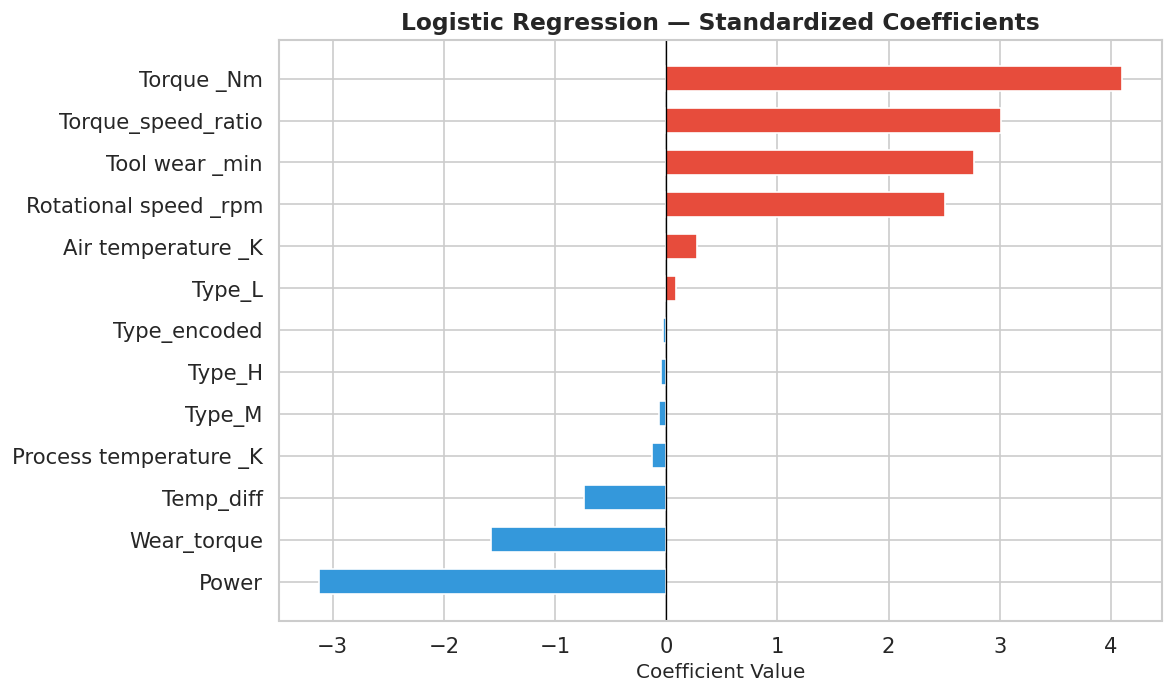

In [36]:
# ── 10.2 Logistic Regression Coefficients ──────────────────────────────────────
coefs = pd.Series(lr_model.coef_[0], index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_coef = ["#e74c3c" if v > 0 else "#3498db" for v in coefs.values]
ax.barh(coefs.index, coefs.values, color=colors_coef, edgecolor="white", height=0.6)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression — Standardized Coefficients", fontweight="bold")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

---
## 11 · Save Model & Artifacts

In [37]:
# ── Create output directory ────────────────────────────────────────────────────
OUTPUT_DIR = "model_artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save the best model
model_path = os.path.join(OUTPUT_DIR, "best_model.joblib")
joblib.dump(best_model, model_path)
print(f"✅ Best model saved: {model_path}")

# Save the scaler
scaler_path = os.path.join(OUTPUT_DIR, "scaler.joblib")
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler saved: {scaler_path}")

# Save label encoder
le_path = os.path.join(OUTPUT_DIR, "label_encoder_type.joblib")
joblib.dump(le_type, le_path)
print(f"✅ Label encoder saved: {le_path}")

# Save feature names
features_path = os.path.join(OUTPUT_DIR, "feature_names.joblib")
joblib.dump(feature_names, features_path)
print(f"✅ Feature names saved: {features_path}")

# Save results
results_path = os.path.join(OUTPUT_DIR, "model_comparison.csv")
results_df.to_csv(results_path)
print(f"✅ Results saved: {results_path}")

print(f"\n📁 All artifacts saved to: {os.path.abspath(OUTPUT_DIR)}/")

✅ Best model saved: model_artifacts/best_model.joblib
✅ Scaler saved: model_artifacts/scaler.joblib
✅ Label encoder saved: model_artifacts/label_encoder_type.joblib
✅ Feature names saved: model_artifacts/feature_names.joblib
✅ Results saved: model_artifacts/model_comparison.csv

📁 All artifacts saved to: /content/model_artifacts/


---
## 12 · Prediction Function

A reusable function that loads the saved model and makes predictions
on new, unseen data.

In [38]:
def predict_machine_failure(
    air_temp: float,
    process_temp: float,
    rotational_speed: int,
    torque: float,
    tool_wear: int,
    product_type: str = "M",
    model_dir: str = "model_artifacts",
) -> dict:
    """
    Predict whether a machine will fail given operational parameters.

    Parameters
    ----------
    air_temp : float          — Air temperature in Kelvin
    process_temp : float      — Process temperature in Kelvin
    rotational_speed : int    — Rotational speed in rpm
    torque : float            — Torque in Nm
    tool_wear : int           — Tool wear in minutes
    product_type : str        — Product quality type: 'L', 'M', or 'H'
    model_dir : str           — Path to saved model artifacts

    Returns
    -------
    dict with keys: prediction (0/1), probability, label, input_features
    """
    # Load artifacts
    model = joblib.load(os.path.join(model_dir, "best_model.joblib"))
    sc = joblib.load(os.path.join(model_dir, "scaler.joblib"))
    le = joblib.load(os.path.join(model_dir, "label_encoder_type.joblib"))
    feat_names = joblib.load(os.path.join(model_dir, "feature_names.joblib"))

    # Engineer features (must match training pipeline)
    temp_diff = process_temp - air_temp
    power = torque * rotational_speed
    torque_speed_ratio = torque / (rotational_speed + 1e-9)
    wear_torque = tool_wear * torque

    type_encoded = le.transform([product_type])[0]
    type_h = 1 if product_type == "H" else 0
    type_l = 1 if product_type == "L" else 0
    type_m = 1 if product_type == "M" else 0

    # Build feature vector in the same order as training
    # NOTE: column names are sanitized (no brackets) to match training pipeline
    feature_dict = {
        "Air temperature _K": air_temp,
        "Process temperature _K": process_temp,
        "Rotational speed _rpm": rotational_speed,
        "Torque _Nm": torque,
        "Tool wear _min": tool_wear,
        "Temp_diff": temp_diff,
        "Power": power,
        "Torque_speed_ratio": torque_speed_ratio,
        "Wear_torque": wear_torque,
        "Type_encoded": type_encoded,
        "Type_H": type_h,
        "Type_L": type_l,
        "Type_M": type_m,
    }

    X_new = pd.DataFrame([feature_dict])[feat_names]
    X_new_scaled = sc.transform(X_new)

    pred = model.predict(X_new_scaled)[0]
    prob = model.predict_proba(X_new_scaled)[0]

    return {
        "prediction": int(pred),
        "label": "⚠️ FAILURE PREDICTED" if pred == 1 else "✅ No Failure",
        "probability_no_failure": round(float(prob[0]), 4),
        "probability_failure": round(float(prob[1]), 4),
        "input_features": feature_dict,
    }

In [39]:
# ── Test the prediction function ────────────────────────────────────────────────
# Scenario 1: Normal operating conditions
result_normal = predict_machine_failure(
    air_temp=300.0,
    process_temp=310.0,
    rotational_speed=1500,
    torque=40.0,
    tool_wear=100,
    product_type="M",
)

print("🔮 Prediction — Normal Conditions:")
for k, v in result_normal.items():
    if k != "input_features":
        print(f"   {k}: {v}")

print()

# Scenario 2: Extreme conditions (likely failure)
result_extreme = predict_machine_failure(
    air_temp=304.0,
    process_temp=313.0,
    rotational_speed=1200,
    torque=70.0,
    tool_wear=220,
    product_type="L",
)

print("🔮 Prediction — Extreme Conditions:")
for k, v in result_extreme.items():
    if k != "input_features":
        print(f"   {k}: {v}")

🔮 Prediction — Normal Conditions:
   prediction: 0
   label: ✅ No Failure
   probability_no_failure: 1.0
   probability_failure: 0.0

🔮 Prediction — Extreme Conditions:
   prediction: 1
   label: ⚠️ FAILURE PREDICTED
   probability_no_failure: 0.0779
   probability_failure: 0.9221


---
## 🎉 Pipeline Complete!

**Summary:**
- Loaded and explored the AI4I 2020 dataset (10,000 samples, 14 features)
- Performed comprehensive EDA with 10+ visualizations
- Engineered 5 new domain-specific features
- Handled severe class imbalance (3.39% failures) using SMOTE
- Trained and tuned 3 models: Logistic Regression, Random Forest, XGBoost
- Best model selected based on F1-Score
- Model, scaler, and encoder saved for deployment
- Prediction function ready for integration